## Module_3:

## Team Members:
Zain Abed and Luke Friscia

## Project Title:
Examaning the Amount of Fibrotic Tissue in Bleomycin-indused Mice



## Project Goal:
This project seeks to analyize fibrotic lung tissue in mice in order to better understand the spread of the spread of the disease with the end goal of using the data to make a lung biopsy device. 

## Disease Background: 

* The incidince of Idiopathic Polmunary Fibrosis (IPF) is around 8 cases per 100,000 people each year and the prevelance is around 25 people per 100,000 individuals. It is also more common among the older population, ages 60 and older. 
* The main risk factor is the smoking of tobbacco and there are some occupational exposure factors such as large amounts of dust  
* Symptoms include shortness of breath, dry cough, fatigue and ultimately repritory failure which leads to death. 
* There is no current cure for IPF but some treatments include; antifibrotic medication, which can slow the progression of the fibrosis, and also oxygen therapy. In extreme cases patients may also need a lung transplant. 
* Fibrosis is caused by abnormal wound healing in the alvioli, where fibroblasts differentiate into myofibroblasts which produce excess collagen which leads to a loss of lung elasticity and scarring. 

## Data-Set: 
The data set that we are analyzing is images from a group of bleomycin-induced mice. The mice are given the antbiotic, bleomycin, to induce pulmonary fibrosis. 3 weeks after the injection they are humanely killed and their lungs are harvested. The lungs are then fixed with paraformaldehyde, mounted into gel, placed under a microscope, fluorescently labeled with an antibody, and viewed under the microscope to create a digital image. The myofibroblasts which are originally shown in green are then converted to black and white to show the images were are using. The images are captured from different tissue depths into the lung. 

Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 



## Data Analyis: 


In [ ]:
# ChatGPT wwas used to help during coding, modification and trouble shooting.
#  OpenAI. (2026). ChatGPT (GPT-5 mini) [Large language model]. [https://openai.com/chatgpt](https://openai.com/chatgpt)

from termcolor import colored #import all the tools
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd
import timeit


# Load the images you want to analyze

filenames = [
    "/Users/zain/Documents/GitHub/Module-3-Fibrosis_Luke_Zain/images/MASK_Sk658 Llobe ch010017.jpg", #defining the path to the images
    "/Users/zain/Documents/GitHub/Module-3-Fibrosis_Luke_Zain/images/MASK_Sk658 Llobe ch010018.jpg",
    "/Users/zain/Documents/GitHub/Module-3-Fibrosis_Luke_Zain/images/MASK_Sk658 Llobe ch010019.jpg",
    "/Users/zain/Documents/GitHub/Module-3-Fibrosis_Luke_Zain/images/MASK_Sk658 Llobe ch010021.jpg",
    "/Users/zain/Documents/GitHub/Module-3-Fibrosis_Luke_Zain/images/MASK_Sk658 Llobe ch010022.jpg",
    "/Users/zain/Documents/GitHub/Module-3-Fibrosis_Luke_Zain/images/MASK_Sk658 Llobe ch010023.jpg",
]

# Enter the depth of each image (in the same order that the images are listed above; you can find these in the .csv file provided to you which is tilted: "Filenames and Depths for Students")

depths = [ #defining the depths
    15,
    1000,
    3000,
    5300,
    7000,
    9900
]

# Make the lists that will be used

images = [] #Initializing the storage for the data
white_counts = []
black_counts = []
white_percents = []

# Build the list of all the images you are analyzing

for filename in filenames: #load the photos 
    img = cv2.imread(filename, 0)
    images.append(img)

# For each image (until the end of the list of images), calculate the number of black and white pixels and make a list that contains this information for each filename.

for x in range(len(filenames)): #convert to binary
    _, binary = cv2.threshold(images[x], 127, 255, cv2.THRESH_BINARY)

    white = np.sum(binary == 255)
    black = np.sum(binary == 0)

    white_counts.append(white) #count pixels
    black_counts.append(black)

# Print the number of white and black pixels in each image.

print(colored("Counts of pixel by color in each image", "yellow"))
for x in range(len(filenames)):
    print(colored(f"White pixels in image {x}: {white_counts[x]}", "white")) #print counts
    print(colored(f"Black pixels in image {x}: {black_counts[x]}", "black"))
    print()

# Calculate the percentage of pixels in each image that are white and make a list that contains these percentages for each filename

for x in range(len(filenames)):
    white_percent = (
        100 * (white_counts[x] / (black_counts[x] + white_counts[x]))) #compute the white pixel percentage
    white_percents.append(white_percent)

# Print the filename (on one line in red font), and below that line print the percent white pixels and depth into the lung where the image was obtained

print(colored("Percent white px:", "yellow"))
for x in range(len(filenames)):
    print(colored(f'{filenames[x]}:', "red"))
    print(f'{white_percents[x]}% White | Depth: {depths[x]} microns') #print the percents with depths
    print()


# Create a DataFrame that includes the filenames, depths, and percentage of white pixels
df = pd.DataFrame({ #save into the csv
    'Filenames': filenames,
    'Depths': depths,
    'White percents': white_percents
})

# Write that DataFrame to a .csv file

df.to_csv('Percent_White_Pixels.csv', index=False)

print("The .csv file 'Percent_White_Pixels.csv' has been created.")

Counts of pixel by color in each image
White pixels in image 0: 27561
Black pixels in image 0: 4166743

White pixels in image 1: 33746
Black pixels in image 1: 4160558

White pixels in image 2: 31331
Black pixels in image 2: 4162973

White pixels in image 3: 23900
Black pixels in image 3: 4170404

White pixels in image 4: 33151
Black pixels in image 4: 4161153

White pixels in image 5: 37508
Black pixels in image 5: 4156796

Percent white px:
/Users/zain/Documents/GitHub/Module-3-Fibrosis_Luke_Zain/images/MASK_Sk658 Llobe ch010017.jpg:
0.6571054458618164% White | Depth: 15 microns

/Users/zain/Documents/GitHub/Module-3-Fibrosis_Luke_Zain/images/MASK_Sk658 Llobe ch010018.jpg:
0.8045673370361328% White | Depth: 1000 microns

/Users/zain/Documents/GitHub/Module-3-Fibrosis_Luke_Zain/images/MASK_Sk658 Llobe ch010019.jpg:
0.7469892501831055% White | Depth: 3000 microns

/Users/zain/Documents/GitHub/Module-3-Fibrosis_Luke_Zain/images/MASK_Sk658 Llobe ch010021.jpg:
0.5698204040527344% White | 

This code above analyzes the selected images and calculates the amount of white and black pixels in an image. Then it calculates the percent of white pixels in the image at the specific depth of the image and creates a .csv file with that data

Linear interpolation: 0.6922867092384299
Quadratic interpolation: 0.7043063423175148


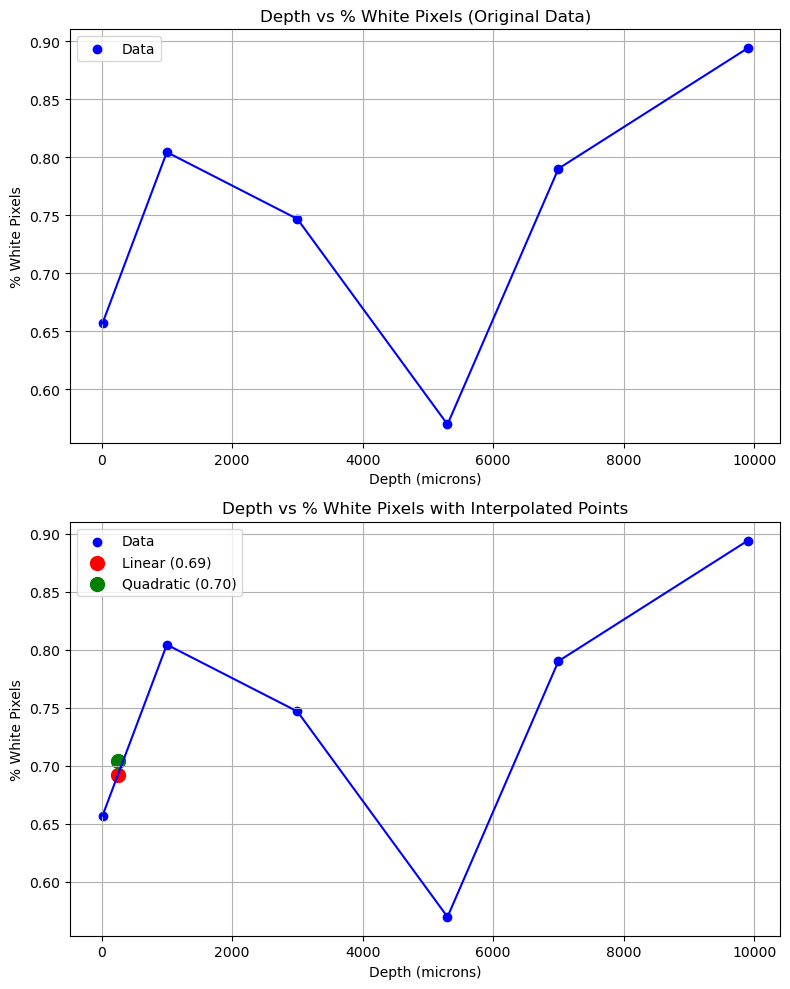

In [4]:
# # Interpolate a point: given a depth, find the corresponding white pixel percentage

interpolate_depth = float(input(colored(
     "Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

x = depths
y = white_percents

# # You can also use 'quadratic', 'cubic', etc.
# Linear interpolation
i_linear = interp1d(x, y, kind='linear')
y_linear = i_linear(interpolate_depth)

# Quadratic interpolation
i_quad = interp1d(x, y, kind='quadratic')
y_quad = i_quad(interpolate_depth)

# Point for code compatibility
interpolate_point = y_linear


print(colored(f'Linear interpolation: {y_linear}', "green"))
print(colored(f'Quadratic interpolation: {y_quad}', "cyan"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# # make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1, figsize=(8, 10))


# Original data 

axs[0].scatter(depths, white_percents, marker='o', color='blue', label='Data')
axs[0].plot(depths, white_percents, color='blue', linestyle='-')  # optional line
axs[0].set_title('Depth vs % White Pixels (Original Data)')
axs[0].set_xlabel('Depth (microns)')
axs[0].set_ylabel('% White Pixels')
axs[0].grid(True)
axs[0].legend()


# Data + interpolated points

axs[1].scatter(depths, white_percents, marker='o', color='blue', label='Data')
axs[1].plot(depths, white_percents, color='blue', linestyle='-')  # optional line

# Linear interpolated point
axs[1].scatter(interpolate_depth, y_linear, color='red', s=100, label=f'Linear ({y_linear:.2f})')

# Quadratic interpolated point
axs[1].scatter(interpolate_depth, y_quad, color='green', s=100, label=f'Quadratic ({y_quad:.2f})')

axs[1].set_title('Depth vs % White Pixels with Interpolated Points')
axs[1].set_xlabel('Depth (microns)')
axs[1].set_ylabel('% White Pixels')
axs[1].grid(True)
axs[1].legend()


# # Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

The code above is used to interpolate the percentage of white pixels at a given depth, it uses both a linear and quadratic interpolation to get a more accurate result. It then creates a graph with the given interpolated point compared to the data of the chosen analyzed images.

## Verify and validate your analysis: 
To verify we checked our interplilated data with nearby, known images from our data set. For this example we interpilated percent white pixels at 250 and got around 0.7% when compared to our nearest known data point of 200 microns which had a percent white pixels of 0.673%; thats only a 2.85% percent error which we found to be acceptable. In people it is seen that fibrosis begins at the periphery of the pulmonary lobe and then progressively extends outwards towards the core of the lung¹.

## Conclusions and Ethical Implications: 
Our main conclusion as shown by the graph and the interpolated data is that there is a general trend that the deeper the tissue sample the higher amount of fibrotic tissue will be found and there will be a higher percentage of white pixel count. This also validated by the data we found through research. 

Ethically, although this data is very useful it is important to remeber that this work is done on mice and does not bypass the input of proffesional physicians or medical personel. Also more data would definitly needs to be collected before the end goal of a byposiy device is ready for humans. Additionally, humans and mice are anatomically different so the shift from one to the other will have to be gradual and well informed so as to not cause more harm than good. 

## Limitations and Future Work: 
* One limitation was the amount of images we used we only used 6 out of the 78 images provided so using more could improve accuracy
* This coincides with the first point but the lack of points on the graph makes the points sparse and thus the interpolation more prone to error so more points on the graph could potentially improve our interpolation
* Another limitation is the smaller size of the original data set. Had the set been larger we could have found a data point that more precisely matched our interpolated data point which would aid in the validation of our calculations 
* Something for future works would be to use a subject that more closely models human pulmonary attributes. For example, ferrets, which were found not only to have histopathological similarity with people but it was also found that bleomycin-induced ferrets had similar circulatory biomarkers to those in human patients with IPF².    

## References:
1. Mai, Cindy et al. “Thin-Section CT Features of Idiopathic Pulmonary Fibrosis Correlated with Micro-CT and Histologic Analysis.” Radiology vol. 283,1 (2017): 252-263. doi:10.1148/radiol.2016152362

2. Wu, S., Driver, I., Luo, M. et al. Ferret model of bleomycin-induced lung injury shares features of human idiopathic pulmonary fibrosis. npj Regen Med 10, 53 (2025). https://doi.org/10.1038/s41536-025-00440-z